# ***Name : Banibrata Manna*** 
# ***Department : IEOR***
# ***Roll : 25M1520***
# ***Course : EE769***
---

# **(1) Likelihood and Loss (Math)**
# 1.1 Learning objectives
* Connect error models to optimization objectives
* Understand MAE as a likelihood consequence
* Interpret assumptions in statistical modeling
* Gain insights for the loss function from the data
# 1.2 Questions
1. Show using derivation that maximizing likelihood under Laplacian error leads to minimizing
mean absolute error.
2. Identify the step in the derivation where the modeling assumption directly determines the
objective. What would change if the assumption changed?
3. If the error distribution becomes heavier-tailed than Laplacian, what qualitative change do you
expect in the loss function?
4. Given only training data, describe a procedure to decide whether MSE or MAE should be
minimized. Justify each step.

# {1.2.1} MLE under Laplacian Noise ⇒ MAE Minimization

## Model Setup

Let the dataset be

$$
\{(x_i, y_i)\}_{i=1}^n, \quad x_i \in \mathbb{R}^d, \; y_i \in \mathbb{R}.
$$

Assume the regression model

$$
y_i = f(x_i;\theta) + \varepsilon_i,
$$

where the errors are i.i.d.:

$$
\varepsilon_i \sim \text{Laplace}(0,b), \quad b > 0.
$$

The Laplace density is

$$
p(\varepsilon) = \frac{1}{2b}\exp\left(-\frac{|\varepsilon|}{b}\right).
$$

Hence,

$$
p(y_i \mid x_i,\theta)
=
\frac{1}{2b}
\exp\left(-\frac{|y_i - f(x_i;\theta)|}{b}\right).
$$

## Likelihood Function

Assuming independence,

$$
L(\theta)
=
\prod_{i=1}^n p(y_i \mid x_i,\theta)
=
\left(\frac{1}{2b}\right)^n
\exp\left(
-\frac{1}{b}
\sum_{i=1}^n
|y_i - f(x_i;\theta)|
\right).
$$

## Log-Likelihood

$$
\ell(\theta)
=
\log L(\theta)
=
-n\log(2b)
-
\frac{1}{b}
\sum_{i=1}^n
|y_i - f(x_i;\theta)|.
$$

## Maximization

Since $-n\log(2b)$ and $\frac{1}{b}$ do not depend on $\theta$,

$$
\arg\max_\theta \ell(\theta)
=
\arg\min_\theta
\sum_{i=1}^n
|y_i - f(x_i;\theta)|.
$$

Thus the MLE solves

$$
\boxed{
\min_\theta \sum_{i=1}^n |y_i - f(x_i;\theta)|
}
$$

which is MAE minimization (up to scaling by $1/n$).

# {1.2.2} Where the Modeling Assumption Determines the Objective

The key identity is

$$
\ell(\theta)
=
\sum_{i=1}^n
\log p(y_i - f(x_i;\theta)).
$$

Hence,

$$
-\ell(\theta)
=
-\sum_{i=1}^n
\log p(y_i - f(x_i;\theta)).
$$

Therefore,

$$
\text{Loss} = -\log(\text{error density}).
$$

### Examples

**Gaussian noise**

$$
p(\varepsilon) \propto \exp(-\varepsilon^2)
$$

$$
\Rightarrow
\text{Loss} = \sum_{i=1}^n (y_i - f(x_i;\theta))^2
$$

(MSE)

**Laplace noise**

$$
p(\varepsilon) \propto \exp(-|\varepsilon|)
$$

$$
\Rightarrow
\text{Loss} = \sum_{i=1}^n |y_i - f(x_i;\theta)|
$$

(MAE)

In general, if

$$
p(\varepsilon) \propto \exp(-\rho(\varepsilon)),
$$

then

$$
\text{Loss}
=
\sum_{i=1}^n
\rho(y_i - f(x_i;\theta)).
$$

Thus the modeling assumption enters exactly through the specification of $p(\varepsilon)$.

# {1.2.3} Heavier-Tailed Errors

Suppose errors follow a Student-t distribution:

$$
p(\varepsilon)
\propto
\left(
1 + \frac{\varepsilon^2}{\nu}
\right)^{-(\nu+1)/2}.
$$

The negative log-likelihood is

$$
\rho(\varepsilon)
=
\frac{\nu+1}{2}
\log\left(
1 + \frac{\varepsilon^2}{\nu}
\right).
$$

As $|\varepsilon| \to \infty$,

$$
\rho(\varepsilon) \sim \log(\varepsilon^2).
$$

Since

$$
\log(\varepsilon^2) \ll |\varepsilon| \ll \varepsilon^2,
$$

the loss grows more slowly than MAE.

Hence heavier tails imply greater robustness to outliers.

# {1.2.4} Choosing Between MSE and MAE Using Only Training Data

## Step 1: Fit Both Models

$$
\hat{\theta}_{\text{MSE}}
=
\arg\min_\theta
\sum_{i=1}^n (y_i - f(x_i;\theta))^2
$$

$$
\hat{\theta}_{\text{MAE}}
=
\arg\min_\theta
\sum_{i=1}^n |y_i - f(x_i;\theta)|
$$

## Step 2: Residual Diagnostics

Define residuals

$$
r_i = y_i - f(x_i;\hat{\theta}).
$$

Examine:

- Histogram
- Q-Q plot
- Tail behavior
- Presence of outliers

## Step 3: Statistical Guidance

- Approximately Gaussian residuals ⇒ MSE is efficient.
- Heavy-tailed residuals or outliers ⇒ MAE is robust.

## Step 4: Cross-Validation

Compute

$$
\text{CV-MSE}, \quad \text{CV-MAE}.
$$

Choose the loss aligned with predictive goals.

# Statistical Insight

- Gaussian errors ⇒ MSE is MLE and asymptotically efficient.
- Laplace errors ⇒ MAE is MLE and asymptotically efficient.
- MSE has unbounded influence.
- MAE has bounded influence.

---

# **(2) Building nuts and bolts in python**
# 2.1 Learning objectives
* Multivariate Gaussian construction
* Covariance validation
* Controlled experimental design
* Gradient descent mechanics
* Closed-form ridge solution
* Numerical vs analytical estimators
# 2.2 Task
1. Implement a data generator with  
* inputs: n_sample, cov_matrix, wt_vector, error_dist_type, error_dist_param  
* outputs: feature matrix X and targets t.  
* You must write the mathematical generative model in equations before coding.  
* Requirements:
    – each feature marginally standard normal  
    – covariance matches cov matrix  
    – add Gaussian / Laplacian / uniform noise  
    – validate covariance (symmetric, PSD, diagonal = 1)  
    – if the weight dimension is one more than that of data then add a column of 1’s  
    – plot ideal vs noisy output  
2. show at least one visualization of two negatively correlated features using a scatter plot  
3. Implement gradient descent with L1/L2 regularization  
4. Implement ridge pseudo-inverse estimator  
5. Build inference module with optional NRMSE/NMAE  
6. Test on synthetic data.

# *{2.2.1} Implementing a data generator*

# Theory of mathematical generative model

Let $n$ be the number of samples and $\Sigma \in \mathbb{R}^{d \times d}$ be a valid covariance matrix such that

$$
\Sigma = \Sigma^\top, \quad \Sigma \succeq 0, \quad \text{diag}(\Sigma) = 1.
$$

## Feature Generation

Generate features as

$$
X_i \sim \mathcal{N}(0, \Sigma), \quad i = 1, \dots, n.
$$

Hence,

$$
X \in \mathbb{R}^{n \times d}, \quad \mathbb{E}[X] = 0, \quad \text{Cov}(X) = \Sigma.
$$

If $w \in \mathbb{R}^{d+1}$, augment

$$
X \leftarrow [\mathbf{1} \;\; X].
$$

## Linear Model

Let $w \in \mathbb{R}^d$ (or $\mathbb{R}^{d+1}$ with intercept).  
The ideal output is

$$
y_i^{\text{ideal}} = X_i^\top w.
$$

## Noise Model

Add i.i.d. noise

- Gaussian:
$$
\varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

- Laplace:
$$
\varepsilon_i \sim \text{Laplace}(0, b)
$$

- Uniform:
$$
\varepsilon_i \sim \mathcal{U}(-a, a)
$$

## Observed Targets

$$
y_i = X_i^\top w + \varepsilon_i
$$

Thus the generative process is

$$
y = Xw + \varepsilon
$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def noise(dist, scale, n):
    match dist:
        case "gaussian":
            return np.random.normal(0, scale, n)
        case "laplacian":
            return np.random.laplace(0, scale, n)
        case "uniform":
            return np.random.uniform(-scale, scale, n)
        case _:
            raise ValueError("Unsupported error distribution")

def validate_covariance(Sigma):
    if not np.allclose(Sigma, Sigma.T):
        raise ValueError("Covariance matrix must be symmetric")
    if np.any(np.linalg.eigvalsh(Sigma) < 0):
        raise ValueError("Covariance matrix must be PSD")
    if not np.allclose(np.diag(Sigma), 1):
        raise ValueError("Diagonal entries must be 1")

def generate_data(n, Sigma, w, noise_="gaussian", noise_param=1.0):
    validate_covariance(Sigma)
    X = np.random.multivariate_normal(np.zeros(Sigma.shape[0]), Sigma, n)
    df = pd.DataFrame(
        np.c_[X, X@w, X@w+noise(noise_, noise_param, n)],
        columns=[*(f"Feature {i+1}" for i in range(X.shape[1])), "y_ideal", "y_noisy"]
    )

    return df

In [3]:
np.random.seed(1520) # For reproducibility

n = 500
Sigma = np.array([          # Can be visualised through pairplot
    [ 1.0, -0.9,  0.7],
    [-0.9,  1.0, -0.5],
    [ 0.7, -0.5,  1.0]
])
w_true = np.array([2., -3., 1.5])

df = generate_data(n, Sigma, w_true, noise_="gaussian", noise_param=0.5)
df.head()

,Feature 1,Feature 2,Feature 3,y_ideal,y_noisy
0,-0.931579,0.537447,-1.278443,-5.393164,-5.623781
1,-0.520577,0.762808,-0.224522,-3.666360,-3.823730
2,1.122020,-1.054559,0.539296,6.216663,5.888845
3,0.168004,0.115275,-0.050727,-0.085908,-0.524678
4,0.097178,0.080414,-0.997522,-1.543166,-1.649246


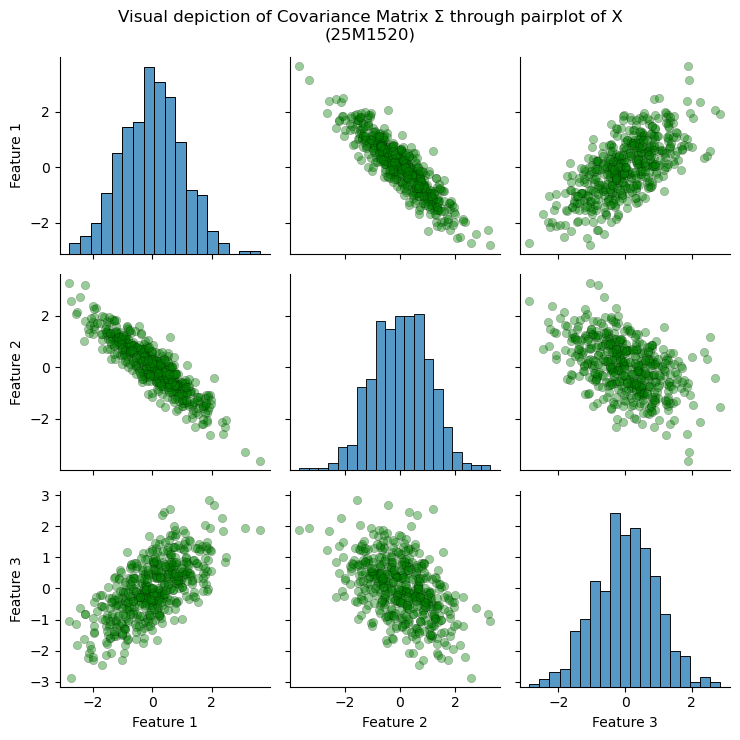

In [4]:
X = df.iloc[:,:3]
y_noisy = df.iloc[:,-1]
n,d = X.shape   # n = #samples, d = #features

sns.pairplot(X, plot_kws={"color": "green", "alpha": 0.4, "edgecolor": "black", "linewidth": 0.3})
plt.suptitle("Visual depiction of Covariance Matrix Σ through pairplot of X\n(25M1520)")
plt.tight_layout()
plt.show()

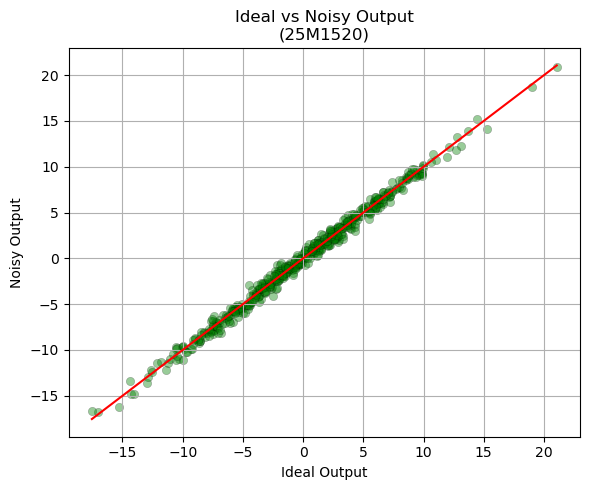

In [5]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["y_ideal"], y=df["y_noisy"], color="green", alpha=0.4, edgecolor="black", linewidth=0.3)
sns.lineplot(x=df["y_ideal"], y=df["y_ideal"], color="red", linewidth=1.5) # Line of perfect correlation for reference
plt.title("Ideal vs Noisy Output\n(25M1520)")
plt.xlabel("Ideal Output")
plt.ylabel("Noisy Output")
plt.grid(True)
plt.tight_layout()
plt.show()


# *{2.2.2} Negative Correlation Visualizations*

**From pairplot above we can see that Feature 1 and Feature 2 are negatively correlated. Similarly Feature 2 and Feature 3 are negatively correlated. Now we plot them here for better visualization**

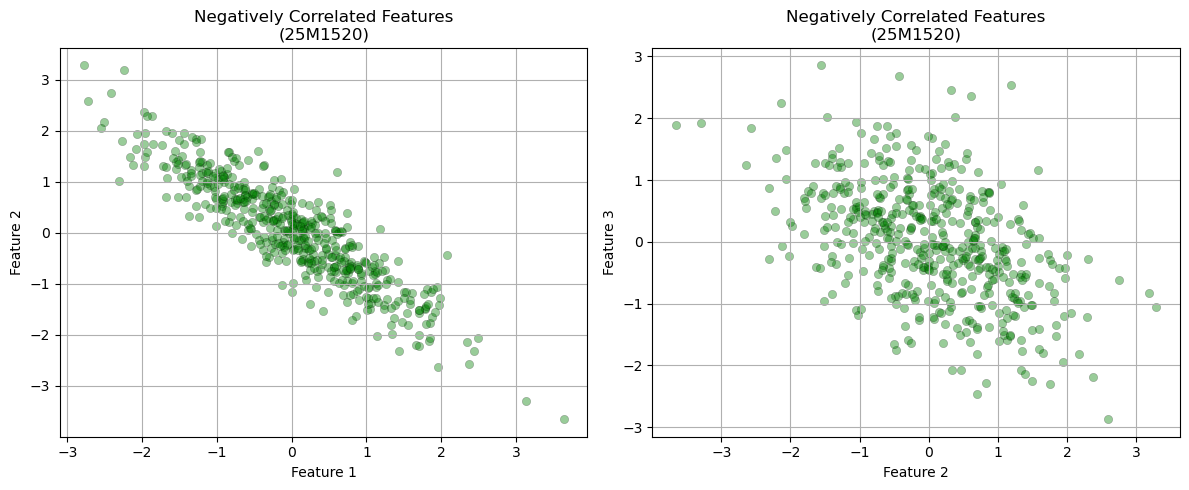

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(ax=axes[0], x=df.iloc[:, 0], y=df.iloc[:, 1], color="green", alpha=0.4, edgecolor="black", linewidth=0.3)
axes[0].set_title("Negatively Correlated Features\n(25M1520)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

sns.scatterplot(ax=axes[1], x=df.iloc[:, 1], y=df.iloc[:, 2], color="green", alpha=0.4, edgecolor="black", linewidth=0.3)
axes[1].set_title("Negatively Correlated Features\n(25M1520)")
axes[1].set_xlabel("Feature 2")
axes[1].set_ylabel("Feature 3")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# *{2.2.3} Gradient descent with L1 and L2*

**Elastic Net Cost Function:**

$$
J(w) = \mathrm{MSE}(w)
+ r\,\lambda \sum_{i=1}^{n} |w_i|
+ (1-r)\,\lambda \sum_{i=1}^{n} w_i^2
$$

where the mixing ratio $r \in [0,1]$ controls the type of regularization:
- $r = 1$  → **pure L1 (Lasso) regularization** *(that's why mixing ratio is also known as **l1_ratio**)*
- $r = 0$  → **pure L2 (Ridge) regularization**
- $0 < r < 1$ → **Elastic Net (L1 + L2)**

**MSE Gradient:**
$$
\mathrm{MSE}(w) = \frac{1}{m} \sum_{j=1}^{m} (y_j - x_j^\top w)^2, \quad
\frac{\partial \mathrm{MSE}}{\partial w} = -\frac{2}{m} X^\top (y - X w)
$$

**L1 Gradient:**
$$
L_1 = \sum_{i=1}^{n} |w_i|, \quad
\frac{\partial L_1}{\partial w_i} = \mathrm{sign}(w_i), \quad
\frac{\partial L_1}{\partial w} = \mathrm{sign}(w)
$$

**L2 Gradient:**
$$
L_2 = \sum_{i=1}^{n} w_i^2, \quad
\frac{\partial L_2}{\partial w_i} = 2 w_i, \quad
\frac{\partial L_2}{\partial w} = 2 w
$$

**Combine all gradients:**
$$
\nabla_w J(w) = \frac{\partial \mathrm{MSE}}{\partial w} + r \lambda \frac{\partial L_1}{\partial w} + (1-r) \lambda \frac{\partial L_2}{\partial w}
$$
$$
\nabla_w J(w) = -\frac{2}{m} X^\top (y - X w) + r \lambda \, \mathrm{sign}(w) + 2 (1-r) \lambda w
$$

**Gradient Descent Update:**
$$
w \gets w - \eta \, \nabla_w J(w)
$$
$$
w \gets w - \eta \Big[ \frac{2}{m} X^\top (X w - y) + r \lambda \, \mathrm{sign}(w) + 2 (1-r) \lambda w \Big]
$$

In [7]:
def gradient_descent(X, y, lr=0.01, epochs=10000, reg_type=None, lambda_=0.0, l1_ratio=0.5, tol=1e-6):
    n,d = X.shape
    w = np.zeros(d)    # Initialize weights of shape (d,)
    Xt = X.T           # Precompute X^T for efficiency in for loop
    scale = 2.0 / n    # Scaling factor for the gradient

    for _ in range(epochs):
        grad = scale*(Xt@(X@w-y))   # Gradient of MSE loss
    
        match reg_type:     # Regularization gradient should be added to the loss gradient
            case None: pass # No regularization
            case "l1" | "l2" | "elastic" if lambda_ == 0.0: raise ValueError("lambda_ must be > 0 when regularization is enabled")
            case "l1": grad += lambda_*np.sign(w)
            case "l2": grad += 2.0*lambda_*w
            case "elastic": grad += lambda_ * (l1_ratio*np.sign(w) + 2.0*(1-l1_ratio)*w)
            case _: raise ValueError("reg_type must be None, 'l1', 'l2', or 'elastic'")

        step = lr*grad
        w -= step        # Update weights
        if np.linalg.norm(step) < tol: break  # Convergence check

    return w

In [8]:
w_gd =          gradient_descent(X, y_noisy)
w_gd_l1 =       gradient_descent(X, y_noisy, reg_type="l1", lambda_=0.2)
w_gd_l2 =       gradient_descent(X, y_noisy, reg_type="l2", lambda_=0.2)
w_gd_elastic =  gradient_descent(X, y_noisy, reg_type="elastic", lambda_=0.2, l1_ratio=0.5)

weights_df = pd.DataFrame(
    {"True Weights": w_true,
    "GD Weights": w_gd, 
    "GD_L1 Weights": w_gd_l1, 
    "GD_L2 Weights": w_gd_l2, 
    "GD_Elastic Weights": w_gd_elastic
    }
)
weights_df

,True Weights,GD Weights,GD_L1 Weights,GD_L2 Weights,GD_Elastic Weights
Feature 1,2.0,1.985455,2.054336,2.176668,2.195402
Feature 2,-3.0,-3.011060,-2.900826,-2.441428,-2.592292
Feature 3,1.5,1.509074,1.403729,1.362121,1.366101


# *{2.2.4} Ridge pseudo-inverse estimator*

**Ridge Regression (Pseudo-Inverse Form):**
$$
\quad
\hat{w}_\lambda = (X^\top X + \lambda I)^{-1} X^\top y
$$
**Updation rule:**
$$
\quad
w \gets (X^\top X + \lambda I)^{-1} X^\top y
$$

In [9]:
def ridge_pseudoinverse(X,y_noisy,lambda_):
    I = np.eye(d)
    return np.linalg.inv(X.T@X + lambda_*I) @ X.T @ y_noisy

w_pi_l2 = ridge_pseudoinverse(X,y_noisy,lambda_=0.2)
w_pi_l2.index = ["Feature 1", "Feature 2", "Feature 3"]
w_pi_l2

Feature 1    1.987504
Feature 2   -3.008447
Feature 3    1.508295
dtype: float64

In [10]:
weights_df["Ridge_pseudo_inverse_weights"] = w_pi_l2
weights_df

,True Weights,GD Weights,GD_L1 Weights,GD_L2 Weights,GD_Elastic Weights,Ridge_pseudo_inverse_weights
Feature 1,2.0,1.985455,2.054336,2.176668,2.195402,1.987504
Feature 2,-3.0,-3.011060,-2.900826,-2.441428,-2.592292,-3.008447
Feature 3,1.5,1.509074,1.403729,1.362121,1.366101,1.508295


# *{2.2.5} Inference Module*

**Normalized Root Mean Squared Error (NRMSE):**
$$
\mathrm{NRMSE}
=
\frac{\sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y}_i)^2}}
{\max(y)-\min(y)}
$$

**Normalized Mean Absolute Error (NMAE):**
$$
\mathrm{NMAE}
=
\frac{\frac{1}{m}\sum_{i=1}^{m}\lvert y_i-\hat{y}_i\rvert}
{\max(y)-\min(y)}
$$


In [11]:
def inference_metrics(y, y_pred, nrmse=True, nmae=True):
    rng = y.max()-y.min() or 1  # Avoid division by zero
    res = {}
    if nrmse: res["NRMSE"] = np.sqrt(((y-y_pred)**2).mean()) / rng
    if nmae:  res["NMAE"] = np.abs(y-y_pred).mean() / rng
    return res

# *{2.2.6} Testing on synthetic data*

In [12]:
metrics_df = pd.DataFrame(
    {col: inference_metrics(y_noisy, X @ weights_df[col]) for col in weights_df.columns}
)
metrics_df

,True Weights,GD Weights,GD_L1 Weights,GD_L2 Weights,GD_Elastic Weights,Ridge_pseudo_inverse_weights
NRMSE,0.013856,0.013855,0.014224,0.018919,0.016197,0.013855
NMAE,0.011137,0.011131,0.011415,0.015252,0.013063,0.011132


---

# **(3) Optimization and Estimation**
# Learning objectives
* Learn to code a gradient descent loop
* Learn to implement stopping criteria
# Tasks
1. Implement gradient descent with L1/L2 regularization
2. Implement ridge pseudo-inverse estimator
3. Build inference module with optional NRMSE/NMAE
4. Test on synthetic data.

# *These are the same questions asked in Q2 so I will write minimal, optimized code reusing what's already defined in Q2 with other unused hyperparameter in Q2*

# Pre-question
Which estimator do you expect to be more stable: gradient descent or pseudo-inverse? Why?

**Answer:** 
*The ridge pseudo-inverse estimator* 
$$
\hat{w}=(X^\top X+\lambda I)^{-1}X^\top y 
$$
*is more stable because regularization improves conditioning and gives the exact optimum,
whereas gradient descent depends on step-size tuning.*

# *Initial data processing phase*

In [13]:
np.random.seed(2026) # For reproducibility

n = 500
Sigma = np.array([          # Covariance matrix is changed to generate a different dataset with Laplacian noise
    [1.0, 0.9, 0.8],
    [0.9, 1.0, 0.7],
    [0.8, 0.7, 1.0]
])
w_true = np.array([1., 2., 3.]) # true weights are changed to generate a different dataset with Laplacian noise

# noise_ and noise_param are changed to generate a different dataset with Laplacian noise
df = generate_data(n, Sigma, w_true, noise_="laplacian", noise_param=0.75)  
df.head()

,Feature 1,Feature 2,Feature 3,y_ideal,y_noisy
0,0.338259,-0.091980,0.989716,3.123447,3.466432
1,0.235393,0.421915,-0.659084,-0.898029,-0.735965
2,0.769707,0.163904,1.415853,5.345074,5.624525
3,0.163400,0.375939,0.356435,1.984584,2.252566
4,2.142966,2.072431,1.342002,10.313836,10.700049


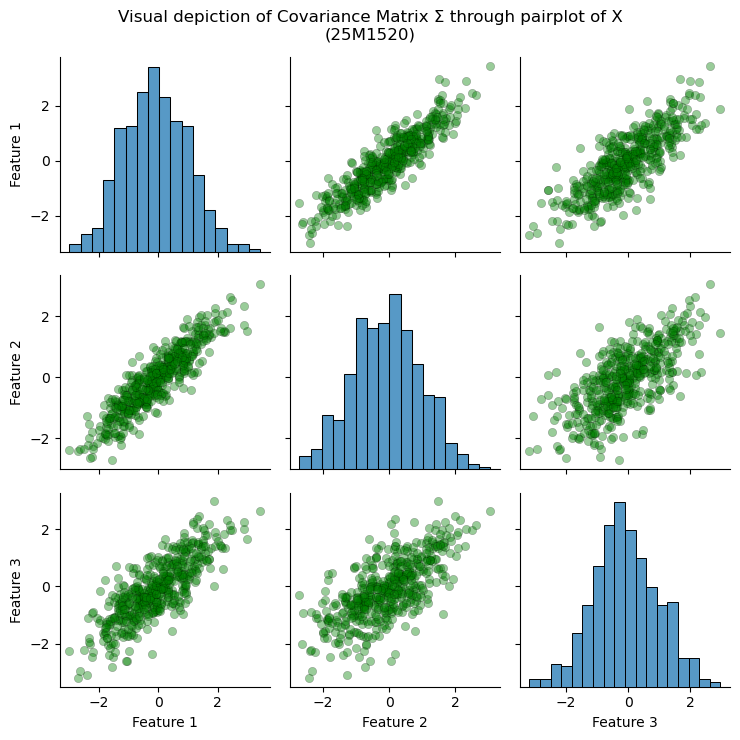

In [14]:
X = df.iloc[:,:3]
y_noisy = df.iloc[:,-1]
n,d = X.shape   # n = #samples, d = #features

sns.pairplot(X, plot_kws={"color": "green", "alpha": 0.4, "edgecolor": "black", "linewidth": 0.3})
plt.suptitle("Visual depiction of Covariance Matrix Σ through pairplot of X\n(25M1520)")
plt.tight_layout()
plt.show()

# *{3.1} Gradient descent with L1 and L2*

In [15]:
w_gd =          gradient_descent(X, y_noisy)
w_gd_l1 =       gradient_descent(X, y_noisy, reg_type="l1", lambda_=0.2)
w_gd_l2 =       gradient_descent(X, y_noisy, reg_type="l2", lambda_=0.2)
w_gd_elastic =  gradient_descent(X, y_noisy, reg_type="elastic", lambda_=0.2, l1_ratio=0.5)

weights_df = pd.DataFrame(
    {"True Weights": w_true,
    "GD Weights": w_gd, 
    "GD_L1 Weights": w_gd_l1, 
    "GD_L2 Weights": w_gd_l2, 
    "GD_Elastic Weights": w_gd_elastic
    }
)
weights_df

,True Weights,GD Weights,GD_L1 Weights,GD_L2 Weights,GD_Elastic Weights
Feature 1,1.0,1.022091,1.054641,1.565025,1.462063
Feature 2,2.0,1.969217,1.888982,1.597008,1.651534
Feature 3,3.0,2.981319,2.920292,2.367272,2.563321


# *{3.2} Ridge pseudo-inverse estimator*

In [16]:
w_pi_l2 = ridge_pseudoinverse(X,y_noisy,lambda_=0.2)
w_pi_l2.index = ["Feature 1", "Feature 2", "Feature 3"]
w_pi_l2

Feature 1    1.025655
Feature 2    1.966824
Feature 3    2.978966
dtype: float64

In [17]:
weights_df["Ridge_pseudo_inverse_weights"] = w_pi_l2
weights_df

,True Weights,GD Weights,GD_L1 Weights,GD_L2 Weights,GD_Elastic Weights,Ridge_pseudo_inverse_weights
Feature 1,1.0,1.022091,1.054641,1.565025,1.462063,1.025655
Feature 2,2.0,1.969217,1.888982,1.597008,1.651534,1.966824
Feature 3,3.0,2.981319,2.920292,2.367272,2.563321,2.978966


# *{3.3} Inference Module*

**Same as before, but with a different random seed to show that the code is not overfitting to a specific dataset**

# *{3.4} Testing on synthetic data*

In [18]:
metrics_df = pd.DataFrame(
    {col: inference_metrics(y_noisy, X @ weights_df[col]) for col in weights_df.columns}
)
metrics_df

,True Weights,GD Weights,GD_L1 Weights,GD_L2 Weights,GD_Elastic Weights,Ridge_pseudo_inverse_weights
NRMSE,0.033457,0.033448,0.033590,0.036453,0.034860,0.033448
NMAE,0.023492,0.023478,0.023703,0.027164,0.025313,0.023479


# Post-question
When do the two estimators disagree and why?

**Answer:** 
*They disagree when gradient descent has not fully converged or due to numerical/implementation differences;
with full convergence and identical objectives, both solutions coincide.*

---

# **(4) Bias-Variance Experiments**
# Learning objectives
* Empirical bias–variance behavior
* Loss mismatch consequences
* Effect of training size
# Tasks
Using Gaussian and Laplacian noise:
1. Show variance shrinks as N increases
2. Show MSE beats MAE under Gaussian noise
3. Show MAE beats MSE under Laplacian noise

Fix validation data. Fix training data size only (not the data itself). Use repeated resampling of
training data. Train model for each resampling of training data and compute output on validation
data. For each validation sample, compute variance in output (simply the statistical variance), and
take average variance across validation samples.

# Pre-question
Which result do you expect to change faster with increasing N : bias or variance?

**Answer:**
*Variance is expected to change faster with increasing N. 
As training size grows, estimator variability reduces due to averaging effects,
while bias is mainly determined by model assumptions and changes slowly.*

# *Initial data processing phase*

In [19]:
np.random.seed(769) # For reproducibility

d = 3
Sigma = np.eye(d)   # Identity covariance for uncorrelated features
w_true = np.arange(1, d+1)  # [1., 2., 3., ... , d.]

In [20]:
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [21]:
N_list = [i for i in range(20,151,10)]    # batch sizes of training data 
n_val = 300

def all_metrics_vs_N(noise_, epoch=30):
    val_data = generate_data(n_val, Sigma, w_true, noise_)  # fixed validation set for all N
    X_val = val_data.iloc[:, :d]
    y_true = val_data["y_ideal"]     # true function (for bias calculation)
    y_val = val_data.iloc[:, -1]   

    bias2_list, var_list, mse_list, mae_list = [], [], [], []
    
    for N in N_list:          # different batches of training data for each N
        
        preds_epoch = []      # will contain epoch-wise predictions for each N
        mse_epoch = []        # will contain epoch-wise MSE for each N
        mae_epoch = []        # will contain epoch-wise MAE for each N

        for _ in range(epoch):  # repeat for multiple resampled training sets
            train_data = generate_data(N, Sigma, w_true, noise_)
            X_train = train_data.iloc[:, :d]
            y_train = train_data.iloc[:, -1]

            model = LinearRegression() if noise_ == "gaussian" else QuantileRegressor(quantile=0.5, alpha=0)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            preds_epoch.append(y_pred)
            mse_epoch.append(mean_squared_error(y_val, y_pred))
            mae_epoch.append(mean_absolute_error(y_val, y_pred))

        preds_epoch = np.array(preds_epoch)  # shape: (epoch, n_val)
        
        mean_pred = preds_epoch.mean(axis=0)
        
        bias2_list.append(((mean_pred - y_true)**2).mean())
        var_list.append(preds_epoch.var(0).mean())
        mse_list.append(np.mean(mse_epoch))
        mae_list.append(np.mean(mae_epoch))

    return bias2_list, var_list, mse_list, mae_list

In [22]:
bias2_g, var_g, mse_g, mae_g = all_metrics_vs_N("gaussian")
bias2_l, var_l, mse_l, mae_l = all_metrics_vs_N("laplacian")

In [23]:
df_plot = pd.DataFrame({
    "N": N_list,

    "Bias2_G": bias2_g,
    "Var_G": var_g,
    "Total_G": np.array(bias2_g) + np.array(var_g),

    "MSE_G": mse_g,
    "MAE_G": mae_g,

    "Bias2_L": bias2_l,
    "Var_L": var_l,
    "Total_L": np.array(bias2_l) + np.array(var_l),

    "MSE_L": mse_l,
    "MAE_L": mae_l,
})
df_plot

,N,Bias2_G,Var_G,Total_G,MSE_G,MAE_G,Bias2_L,Var_L,Total_L,MSE_L,MAE_L
0,20,0.010125,0.218137,0.228262,1.199395,0.866560,0.018531,0.660882,0.679413,2.558208,1.205503
1,30,0.003736,0.152533,0.156269,1.153012,0.847263,0.008506,0.254579,0.263086,2.153392,1.091265
2,40,0.006307,0.101202,0.107509,1.126541,0.841503,0.018615,0.184424,0.203039,2.064447,1.059199
3,50,0.002405,0.083959,0.086364,1.082930,0.823912,0.008834,0.140429,0.149263,2.048366,1.048953
4,60,0.001274,0.080380,0.081654,1.089294,0.825838,0.006994,0.130370,0.137364,2.009541,1.036480
5,70,0.001400,0.055521,0.056921,1.056641,0.814098,0.001494,0.086909,0.088403,1.978794,1.024808
6,80,0.002577,0.049290,0.051868,1.052476,0.813214,0.001274,0.087229,0.088503,1.966487,1.019611
7,90,0.001058,0.042646,0.043705,1.039695,0.806493,0.003361,0.075171,0.078533,1.954453,1.013774
8,100,0.000845,0.035810,0.036655,1.036738,0.806246,0.002128,0.053719,0.055847,1.925968,1.003697
9,110,0.001231,0.032296,0.033527,1.029004,0.802048,0.004666,0.037886,0.042552,1.916560,1.001324


# *{4.1} Shrinkage of variance with increasing N*

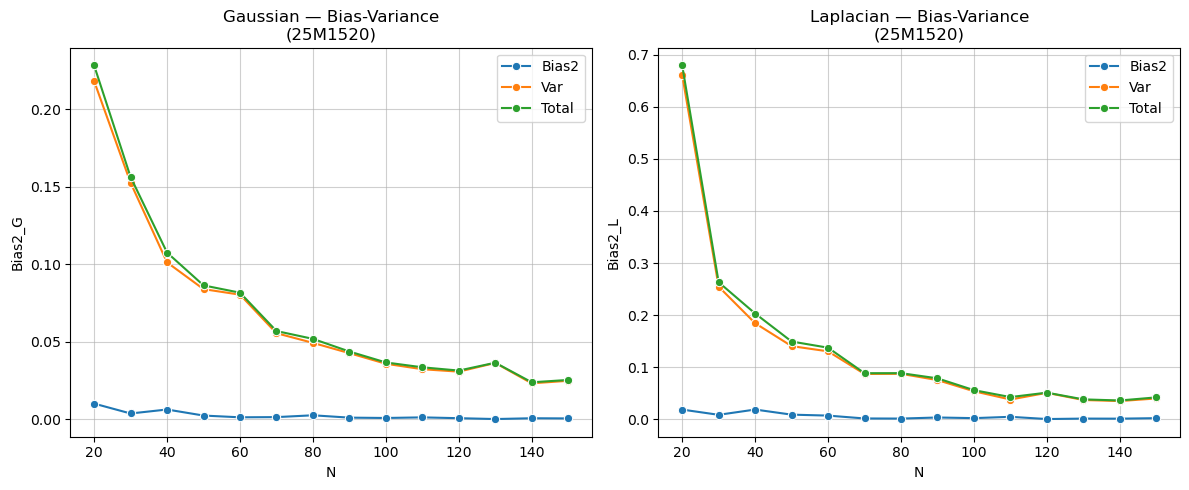

In [24]:
noise_tags = ["G", "L"]
titles = ["Gaussian", "Laplacian"]

fig1, axes1 = plt.subplots(1, 2, figsize=(12,5))

for col, (tag, title) in enumerate(zip(noise_tags, titles)):
    for m in ["Bias2", "Var", "Total"]:
        sns.lineplot(ax=axes1[col], data=df_plot, x="N", y=f"{m}_{tag}", marker="o", label=m)
    axes1[col].set_title(f"{title} — Bias-Variance\n(25M1520)")
    axes1[col].grid(True,alpha=0.6)

plt.tight_layout()
plt.show()

# **Interpretation:**
*The plots confirm the expected bias–variance behavior with increasing training size (N).
Variance decreases rapidly as (N) grows because the estimator becomes more stable under repeated resampling, reflecting the averaging effect of larger datasets. In contrast, bias changes only marginally since it is governed by the model class and underlying assumptions rather than sample size.*

*Consequently, the total error reduction observed for larger (N) is primarily driven by variance shrinkage. This empirical observation aligns with the theoretical bias–variance tradeoff, where increasing data mainly reduces estimation uncertainty while leaving structural approximation error largely unchanged.*

# *{4.2} MSE beats MAE under Gaussian noise*

# *{4.3} MAE beats MSE under Laplacian noise*

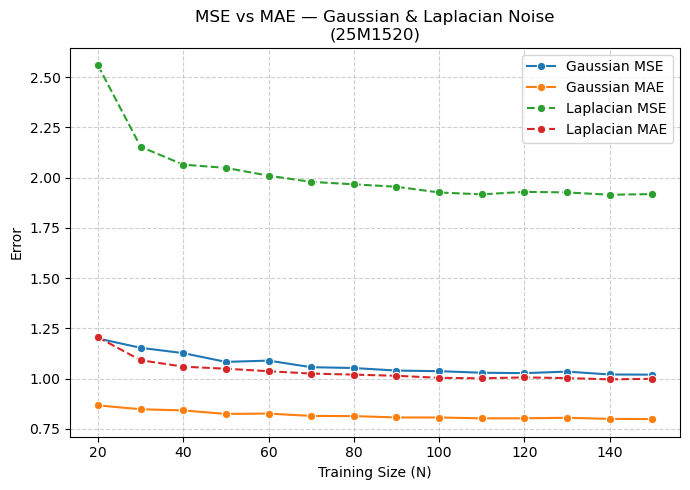

In [25]:
plt.figure(figsize=(7,5))

for metric in ["MSE", "MAE"]:
    sns.lineplot(data=df_plot, x="N", y=f"{metric}_G", marker="o", label=f"Gaussian {metric}")

for metric in ["MSE", "MAE"]:
    sns.lineplot(data=df_plot, x="N", y=f"{metric}_L", marker="o", linestyle="--", label=f"Laplacian {metric}")

plt.title("MSE vs MAE — Gaussian & Laplacian Noise\n(25M1520)")
plt.xlabel("Training Size (N)")
plt.ylabel("Error")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

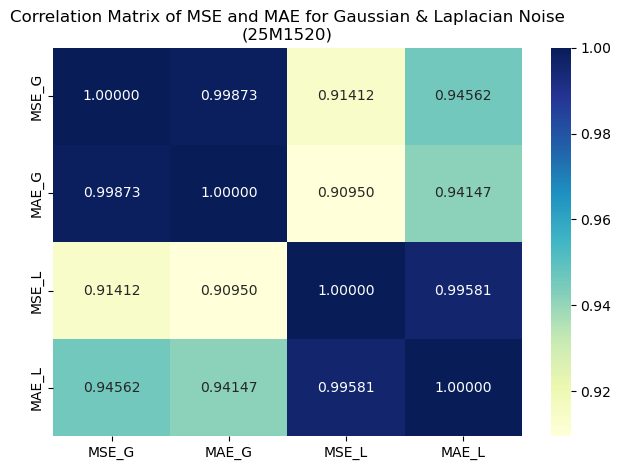

In [26]:
cols = ["MSE_G", "MAE_G", "MSE_L", "MAE_L"]
df_corr = df_plot[cols].corr()  # Correlation matrix for MSE and MAE columns only
sns.heatmap(df_corr, annot=True, cmap="YlGnBu", fmt=".5f")
plt.title("Correlation Matrix of MSE and MAE for Gaussian & Laplacian Noise\n(25M1520)")
plt.tight_layout()
plt.show()

# **Use of Correlation Instead of Direct Value Comparison**

* *Raw error values (MSE, MAE) for different noise types can be on different scales:*

    * *MSE squares the deviations → larger values for heavy-tailed noise.*
    * *MAE uses absolute deviations → smaller values for the same data.*

* *Directly comparing numbers like MSE_G vs MAE_L can be misleading, because similarity in magnitude does not necessarily mean similar behavior across training sizes or samples.*

* *Correlation measures the linear relationship between two series, ignoring scale differences.*

* *Correlation is scale-independent, so it reveals structural similarity in behavior rather than absolute magnitude.*

* *Gaussian MSE measures typical squared deviations.*

* *Laplacian MAE measures typical absolute deviations.*

* *Both essentially track spread of the “bulk” of the data: when the data becomes more variable (e.g., smaller training sizes → higher variance), both metrics increase.*

* *High correlation captures this shared response to data variability, which raw value comparison cannot.*

# **Observation: Gaussian MSE vs Laplace MAE Correlation**
* *MSE is optimal for Gaussian noise (minimizes squared deviations).*

* *MAE is optimal for Laplacian noise (minimizes absolute deviations).*

* *Gaussian MSE and Laplacian MAE tend to be closer/correlated than other combinations.*

* *Reason: Both primarily measure the central spread of typical data points, ignoring extreme outliers.*

# Post-question
Which result contradicted your intuition?

**Answer:**
*No strong contradiction was observed; the empirical results matched intuition.
Variance decreased noticeably with N, while bias remained relatively stable.*

---

# **(5) Regularization Behavior**
# Learning objectives
* Bias–variance tradeoff via λ
* L1 sparsity
* instability with correlated variables
# Tasks
1. Empirically confirm that validation error minimized at λ > 0
2. Demonstrate L1 variable elimination
3. Show instability with correlated features and stabilization via L2

# Pre-question
Why should λ = 0 almost never be optimal?

**Answer:**

*When $\lambda = 0$ , the model reduces to ordinary least squares, which minimizes
training error only and ignores model variance. In finite-sample and noisy settings,
this leads to overfitting, especially when features are correlated or the problem is
ill-conditioned. Introducing a positive regularization parameter $\lambda > 0$
slightly increases bias but significantly reduces variance, resulting in lower
validation and test error. Hence,  $\lambda = 0$  is almost never optimal for
generalization.*
$$

# *Initial data processing phase*

In [27]:
np.random.seed(769) # For reproducibility

n = 200
d = 10

# true weights are set to zero to focus on the effect of covariance structure without influence of true signal
w_true = np.zeros(d) 
w_true[:3] = [3, -2, 1]  # Only first 3 features are relevant, other 7 features are noise features

# Sigma is generated as a random symmetric PSD matrix with diag=1
A = np.random.randn(d, d)
Sigma = A @ A.T          # symmetric & PSD

D = np.sqrt(np.diag(Sigma))
Sigma = Sigma / np.outer(D, D)   # diag = 1, symmetric, PSD

In [28]:
data = generate_data(n, Sigma, w_true, noise_="gaussian")  # fixed validation set for all λ
X = data.iloc[:, :d]
y = data.iloc[:, -1]   

from sklearn.model_selection import train_test_split

# 6% of 5000 = 300 samples for validation, rest for training
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.06, random_state=769)  

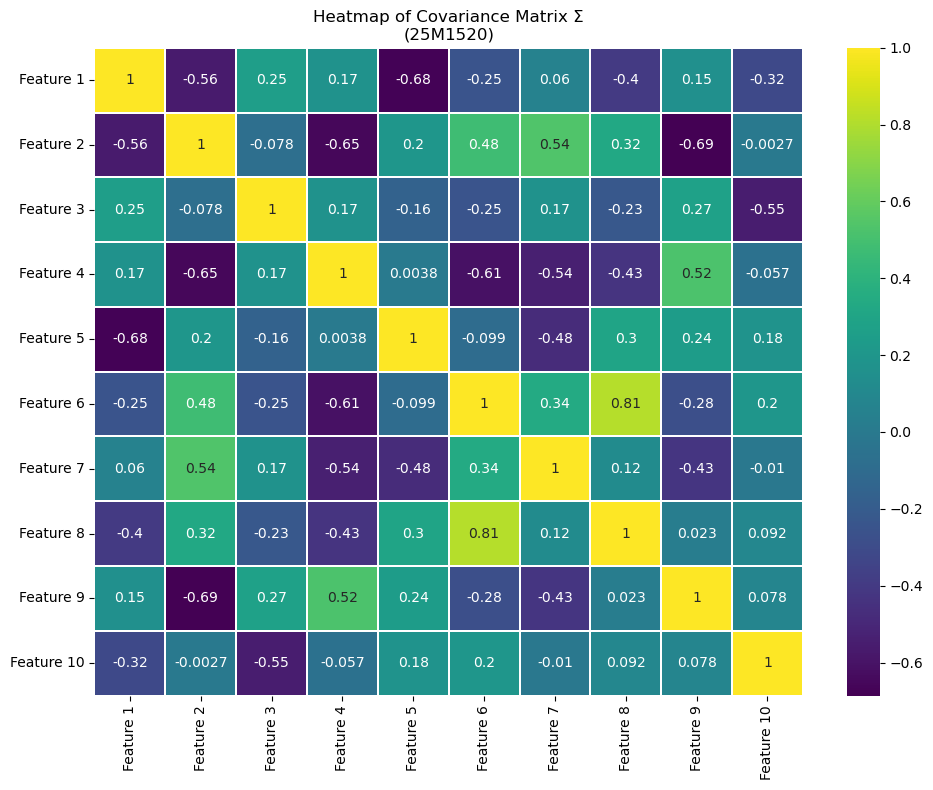

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(Sigma, cmap="viridis", annot=True, linewidths=0.1, xticklabels=X.columns, yticklabels=X.columns)
plt.title("Heatmap of Covariance Matrix Σ\n(25M1520)")
plt.tight_layout()
plt.show()

# *{5.1} Empirical confirmation of minimized validation error at λ > 0*

In [30]:
# A range of λ values from 10^-4 to 10^1, spaced logarithmically for better coverage of small values
lambdas = np.logspace(-4, 1, 30) 

def experiment_with_λ(reg_type):
    val_errors = []
    weights = []
    for lam in lambdas:
        w = gradient_descent(X_train, y_train, reg_type=reg_type, lambda_=lam)
        weights.append(w)
    
        y_val_pred = X_val @ w
        val_errors.append(np.mean((y_val - y_val_pred)**2))
    
    best_lambda = lambdas[np.argmin(val_errors)]
    best_weights = weights[np.argmin(val_errors)]
    
    return best_lambda, val_errors, best_weights

best_lambda_gd_l1, val_errors_gd_l1, best_weights_gd_l1 = experiment_with_λ("l1")
best_lambda_gd_l2, val_errors_gd_l2, best_weights_gd_l2 = experiment_with_λ("l2")

In [31]:
print(f"Best λ (λ*) with lasso regularization: {best_lambda_gd_l1}")
print(f"Best λ (λ*) with ridge regularization: {best_lambda_gd_l2}")

print("\nBest weights at λ* :")
best_weights = pd.DataFrame(
    {
        "Lasso_Weight" : best_weights_gd_l1,
        "Ridge_Weight" : best_weights_gd_l2
    }
)
best_weights

Best λ (λ*) with lasso regularization: 0.01743328822199989
Best λ (λ*) with ridge regularization: 0.002395026619987486

Best weights at λ* :


,Lasso_Weight,Ridge_Weight
Feature 1,2.966206,2.969080
Feature 2,-2.124498,-2.081965
Feature 3,0.926934,0.982062
Feature 4,-0.000003,-0.007304
Feature 5,-0.021253,-0.100130
Feature 6,0.000047,-0.058698
Feature 7,-0.081348,-0.169992
Feature 8,0.000020,0.070829
Feature 9,-0.096023,-0.125929
Feature 10,0.008864,0.078952


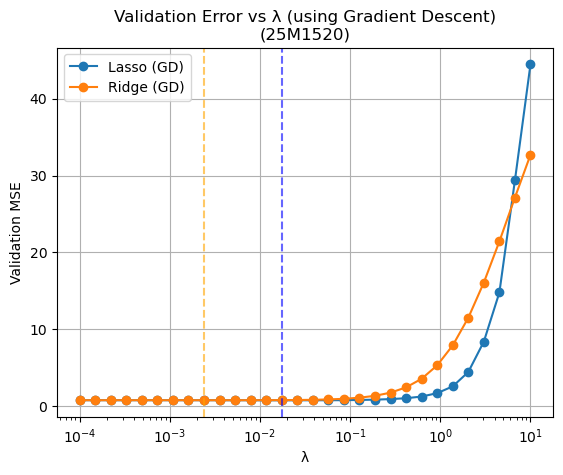

In [32]:
plt.semilogx(lambdas, val_errors_gd_l1, marker='o', label='Lasso (GD)')
plt.semilogx(lambdas, val_errors_gd_l2, marker='o', label='Ridge (GD)')

plt.axvline(best_lambda_gd_l1, color='blue', linestyle='--', alpha=0.6)
plt.axvline(best_lambda_gd_l2, color='orange', linestyle='--', alpha=0.6)

plt.xlabel("λ")
plt.ylabel("Validation MSE")
plt.title("Validation Error vs λ (using Gradient Descent)\n(25M1520)")
plt.legend()
plt.grid(True)
plt.show()

# *{5.2} L1 regularization eliminates variables*

In [33]:

def check_sparsity(feature_val):
    eliminated = feature_val.loc[np.abs(feature_val.values) < tol]   
    
    if len(eliminated):
        print(f"Features eliminated : {len(eliminated)}")
        print(f"\nEliminated features:\n{eliminated}")
    else:
        print("No features eliminated!!")
    
    return [feat for feat in eliminated.index]

tol = 1e-3
best_weights

,Lasso_Weight,Ridge_Weight
Feature 1,2.966206,2.969080
Feature 2,-2.124498,-2.081965
Feature 3,0.926934,0.982062
Feature 4,-0.000003,-0.007304
Feature 5,-0.021253,-0.100130
Feature 6,0.000047,-0.058698
Feature 7,-0.081348,-0.169992
Feature 8,0.000020,0.070829
Feature 9,-0.096023,-0.125929
Feature 10,0.008864,0.078952


In [34]:
l1_eliminated = check_sparsity(best_weights["Lasso_Weight"])

Features eliminated : 3

Eliminated features:
Feature 4   -0.000003
Feature 6    0.000047
Feature 8    0.000020
Name: Lasso_Weight, dtype: float64


In [35]:
l2_eliminated = check_sparsity(best_weights["Ridge_Weight"])

No features eliminated!!


# *{5.3} Instability with correlated features and stabilization via L2*

In [36]:
l1_eliminated

['Feature 4', 'Feature 6', 'Feature 8']

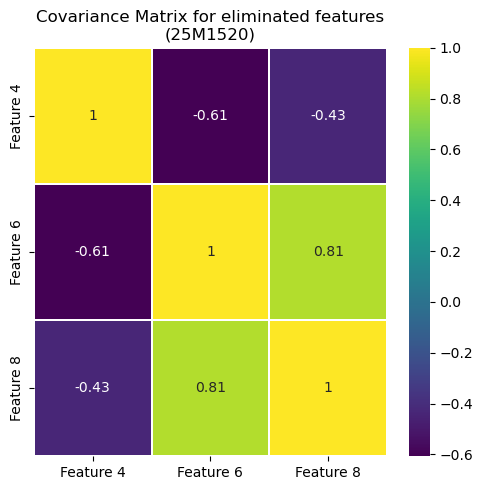

In [37]:
index_ = [int(name[-1])-1 for name in l1_eliminated]    # index extraction for eliminated features
temp = Sigma[np.ix_(index_, index_)]

plt.figure(figsize=(5,5))
sns.heatmap(temp, cmap="viridis", annot=True, linewidths=0.1, xticklabels=l1_eliminated, yticklabels=l1_eliminated)
plt.title("Covariance Matrix for eliminated features\n(25M1520)")
plt.tight_layout()
plt.show()

In [38]:
best_weights.loc[['Feature 6', 'Feature 8']]

,Lasso_Weight,Ridge_Weight
Feature 6,0.000047,-0.058698
Feature 8,0.000020,0.070829


# **Observation:**
When features are highly correlated, $L_1$ (Lasso) acts erratically—it might pick one feature and ignore the other. $L_2$ (Ridge) is much more stable because it distributes the weight across correlated features.

# Post-question
When does L1 fail to stabilize correlated features?

**Answer:**
*L1 regularization (Lasso) fails to stabilize correlated features when predictors are
strongly correlated and carry similar information. In such cases, multiple sparse
solutions achieve nearly the same objective value, causing Lasso to arbitrarily select
one feature and discard others. Small changes in the data or training split can lead to
different selected features, resulting in unstable coefficient estimates. L2
regularization mitigates this issue by shrinking correlated coefficients together.*

---

# **Bonus Module - Insight extension**

# Choose one:
* Implement Huber loss and compare
* Design a diagnostic for automatic loss selection
* Propose a new regularizer and test it
* Or any other interesting experiment
Must include prediction and reflection.

# *Huber Loss*

*Huber loss is the "best of both worlds" in the machine learning world. It behaves like Mean Squared Error (MSE) when the error is small, but switches to Mean Absolute Error (MAE) when the error is large. This makes it robust to outliers while remaining smooth and differentiable at the center.The Mathematical FormulaThe loss function is defined by a threshold parameter $\delta$ (delta), which determines the transition point:*

$$
L_{\delta}(y, f(x)) = 
\begin{cases} 
\frac{1}{2}(y - f(x))^2 & \text{for } |y - f(x)| \leq \delta \\
\delta(|y - f(x)| - \frac{1}{2}\delta) & \text{otherwise}
\end{cases}
$$

# *Initial data processing phase*

In [39]:
np.random.seed(769) # For reproducibility

n = 500
d = 3
w_true = np.arange(1,d+1)

A = np.random.randn(d, d)
Sigma = A @ A.T          # symmetric & PSD
D = np.sqrt(np.diag(Sigma))
Sigma = Sigma / np.outer(D, D)   # diag = 1, symmetric, PSD

In [40]:
data = generate_data(n, Sigma, w_true, noise_="gaussian")  # fixed validation set for all λ
X = data.iloc[:, :d]
y = data.iloc[:, -1]   

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=769)  

w_gd = gradient_descent(X_train, y_train)

# *Implementation*

In [41]:
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true-y_pred
    is_small_error = np.abs(error)<=delta
    
    # Squared error for small values
    squared_loss = 0.5*np.square(error)
    
    # Linear error for large values
    linear_loss = delta * (np.abs(error) - 0.5*delta)
    
    return np.where(is_small_error, squared_loss, linear_loss).mean()

print(f"Huber Loss: {huber_loss(y_val, X_val@w_gd, delta=1.0)}")

Huber Loss: 0.42928262378400645


---